# Why does norm-capping "drop" on `tc11_hard`?

**The flagged row** (thesis Table `tab:dbpedia_cap_per_tc`, 10% sub-corpus):

| Test case | vanilla | p2_classic | bound (global) | bound (cap@16) |
|---|---|---|---|---|
| **tc11_hard** | 0.720 | **0.795** | 0.640 | **0.608** |

Two things look wrong here: (a) both bound columns sit *below* vanilla — unusual,
the bound wins almost everywhere else; and (b) the cap makes the bound *worse*
(0.640 → 0.608), the opposite of its job. This notebook takes both apart on real
data. The short version is that **(b) is mostly a measurement artifact**, while
**(a) is the real, robust finding**.

> **Method note.** All numbers below are the full-corpus `most_specific` bound, the
> only variant with the complete `init + no-cap-final + cap-final` triple saved on
> disk (`output/dbpedia/p2_bound_specific{,_cap16}`). It reproduces the same
> `tc11_hard` "drop" as the `uniform` bound behind the thesis table (−0.034 here vs
> −0.039 uniform). Everything is cached by `scripts/_invest_tc11hard.py`.

---

## TL;DR

**Part A — the "cap drops `tc11_hard`" effect is fragile, not a mechanism.** The
−0.034 domain-mean gap flips sign under every reasonable perturbation:

| perturbation | `tc11_hard` Δ (cap − no-cap) |
|---|---|
| as reported (standardize lens, domain-mean) | **−0.034** |
| **raw lens** instead of standardize | **+0.054** |
| **decay** init instead of most_specific | **+0.011** |
| **entity-weighted** (micro) instead of domain-mean (macro) | **+0.047** |
| **drop the 8-entity `movies` domain** | **+0.034** |

It is driven almost entirely by **`movies_hard`, which has 8 test entities**
(cap 0.750 → 0.375 = three entities flipping). On the statistically meaningful
domains the cap *helps*: `people` (n=8000) **+0.052**, `species` **+0.117**,
`cities` **+0.071**, `books` (n=1028) **+0.002**. At the entity level the cap helps
`tc11_hard` overall (**+0.047**). So capping is **not** doing something pathological
to `tc11`.

**Part B — the real finding: the bound init has no `recordLabel` channel.** `tc11`
= "Person with ≥2 `recordLabel.RecordLabel`", but `recordLabel` is one of the
relations with **no pretrained code**, and `concept_bound_vectors` **skips every
edge whose relation has no code** (`_dbpedia_compare.py:805`). The init therefore
cannot represent the record-label count at all; its only `tc11` signal is an
**indirect degree proxy** (norm ↔ degree ρ = 0.66, norm ↔ label-count ρ = 0.17).
That is why — uniquely among the splits — the bound only *ties* vanilla on
`tc11_hard` instead of beating it. And because the two methods are essentially
tied here, the equal-weighted domain mean is free to wobble ±0.05 on the noise of
two tiny domains. **Part A is a symptom of Part B.**

> **What this notebook does _not_ claim.** An earlier draft attributed the drop to
> "capping freezes/unfreezes the heavy-norm positive hubs". An adversarial check
> refuted that: the freeze→drift signature is *identical* in `tc09_hard` (where the
> cap *helps*), capping does not change `AUC(norm)` (0.637 → 0.637), and at the
> entity level capping helps the `tc11` tail too (+0.02). That hypothesis is shown
> and rejected in §5.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ART = ROOT / "notebooks" / "dbpedia_tc11hard"

R = json.loads((ART / "results.json").read_text())
A = np.load(ART / "arrays.npz")
CAP = R["meta"]["cap"]
print("variant:", R["meta"]["variant"], "| init:", R["meta"]["init_tag"], "| cap:", CAP)
print("(regenerate the cache with:  .venv/bin/python scripts/_invest_tc11hard.py )")

variant: specific | init: boundinit_specific_full_p2 | cap: 16.0
(regenerate the cache with:  .venv/bin/python scripts/_invest_tc11hard.py )


## 1 · What `tc11_hard` tests

`tc11` is the DLCC qualified-cardinality concept **`Person ⊓ ≥2 recordLabel.RecordLabel`**
— a person signed to **two or more** distinct record labels. The benchmark's *hard*
negatives are Persons with **exactly one** record label, so `tc11_hard` is a pure
counting question: tell **"≥2"** apart from **"exactly 1"**. Confirmed on `graph.nt`:

In [2]:
dc = R["degree_corr"]["tc11_hard"]
print("tc11_hard  (recordLabel edges per entity, counted on graph.nt)")
print(f"  positives : median = {dc['rel_count_pos_median']:.0f} record labels "
      f"({dc['rel_count_pos_ge2_frac']:.0%} have >=2)")
print(f"  hard negs : median = {dc['rel_count_neg_median']:.0f} record label "
      f"({dc['rel_count_neg_eq1_frac']:.0%} have exactly 1)")
print("  -> a genuine '>=2 vs exactly-1' cardinality split.")

tc11_hard  (recordLabel edges per entity, counted on graph.nt)
  positives : median = 3 record labels (84% have >=2)
  hard negs : median = 1 record label (54% have exactly 1)
  -> a genuine '>=2 vs exactly-1' cardinality split.


## 2 · Part A — the "drop" flips sign under every reasonable perturbation

A real mechanism should be robust to the eval lens, the init variant, and how splits
are averaged. This one is not: the sign of the `tc11_hard` cap effect changes in all
three. The same row that is **−0.034** under (standardize lens, domain-mean,
most_specific) is **positive** under the raw lens, under entity-weighting, and under
the decay init.

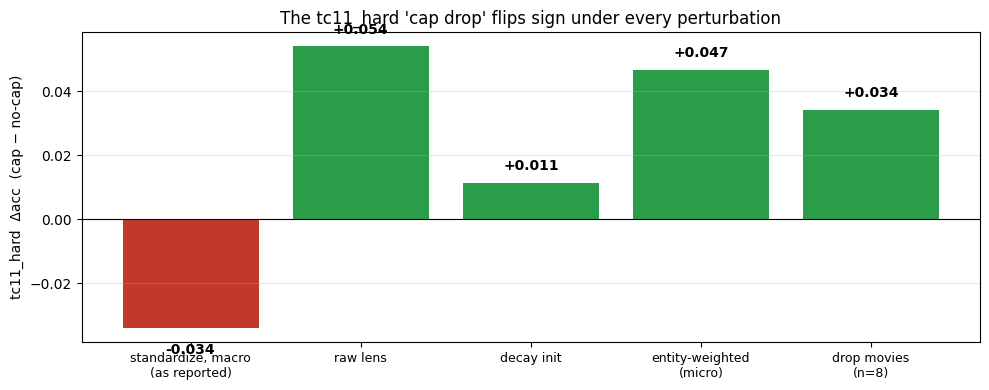

standardize Δ=-0.034   raw Δ=+0.054
variants:  uniform Δ=-0.039  most_specific Δ=-0.034  decay Δ=+0.011
macro Δ=-0.034   micro (entity-weighted) Δ=+0.047


In [3]:
ls = R["lens_sensitivity"]["tc11_hard"]
vs = R["variant_sensitivity"]
pm = R["per_domain_final"]["tc11_hard"]

perturb = [
    ("standardize, macro\n(as reported)", ls["standardize"]["delta"]),
    ("raw lens", ls["raw"]["delta"]),
    ("decay init", vs["decay"]["delta"]),
    ("entity-weighted\n(micro)", pm["micro_delta"]),
    ("drop movies\n(n=8)", pm["macro_delta_leave_one_out"]["movies"]),
]
labels = [p[0] for p in perturb]
vals = [p[1] for p in perturb]
colors = ["#c0392b" if v < 0 else "#2a9d4a" for v in vals]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(vals)), vals, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("tc11_hard  Δacc  (cap − no-cap)")
ax.set_title("The tc11_hard 'cap drop' flips sign under every perturbation")
for i, v in enumerate(vals):
    ax.text(i, v + (0.004 if v >= 0 else -0.008), f"{v:+.3f}", ha="center", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"standardize Δ={ls['standardize']['delta']:+.3f}   raw Δ={ls['raw']['delta']:+.3f}")
print(f"variants:  uniform Δ={vs['uniform']['delta']:+.3f}  most_specific Δ={vs['most_specific']['delta']:+.3f}  decay Δ={vs['decay']['delta']:+.3f}")
print(f"macro Δ={pm['macro_delta']:+.3f}   micro (entity-weighted) Δ={pm['micro_delta']:+.3f}")

## 3 · Part A, cont. — one 8-entity domain manufactures the number

The thesis metric is the **mean over domains** (each of the 6 domains weighted
equally regardless of size). For `tc11_hard` two of those domains — `movies`
(**8** test entities) and `albums` (**14**) — are far too small to estimate an
accuracy: a single entity flipping moves their score by 0.07–0.12. The bar chart
below shows the per-domain cap effect against the (log) test-set size: every
**large** domain is green (cap helps), and the only red bars are the two tiny ones.
The `movies` domain alone (cap 0.750 → 0.375 = 3 of 8 entities) is the **only**
domain whose removal flips the domain-mean back to positive.

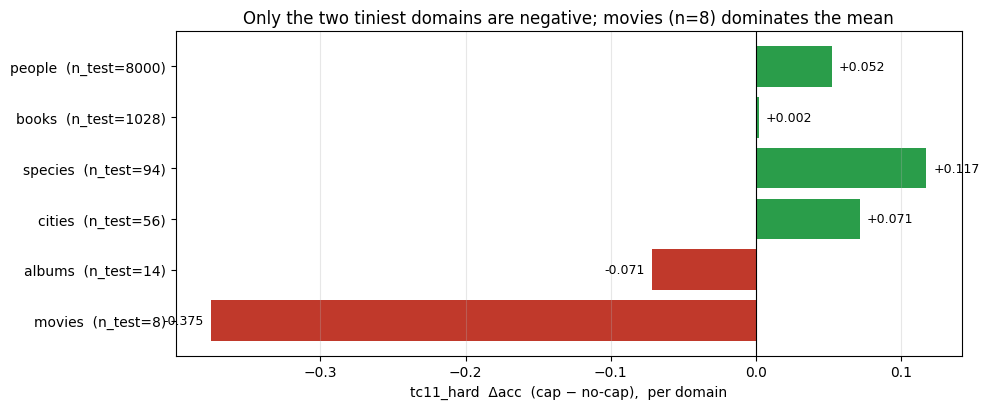

leave-one-domain-out domain-mean Δ (cap − no-cap):
  full (all 6 domains): -0.034
  without movies   : +0.034  <-- removing this flips the sign to POSITIVE
  without albums   : -0.027
  without cities   : -0.055
  without species  : -0.064
  without books    : -0.041
  without people   : -0.051


In [4]:
pd = R["per_domain_final"]["tc11_hard"]["per_domain"]
loo = R["per_domain_final"]["tc11_hard"]["macro_delta_leave_one_out"]
doms = sorted(pd, key=lambda d: pd[d]["n_test"])
deltas = [pd[d]["delta"] for d in doms]
ns = [pd[d]["n_test"] for d in doms]
colors = ["#c0392b" if v < 0 else "#2a9d4a" for v in deltas]

fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.barh(range(len(doms)), deltas, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(range(len(doms)))
ax.set_yticklabels([f"{d}  (n_test={pd[d]['n_test']})" for d in doms])
ax.set_xlabel("tc11_hard  Δacc  (cap − no-cap),  per domain")
ax.set_title("Only the two tiniest domains are negative; movies (n=8) dominates the mean")
for i, (v, n) in enumerate(zip(deltas, ns)):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print("leave-one-domain-out domain-mean Δ (cap − no-cap):")
base = R["per_domain_final"]["tc11_hard"]["macro_delta"]
print(f"  full (all 6 domains): {base:+.3f}")
for d in doms:
    flag = "  <-- removing this flips the sign to POSITIVE" if loo[d] > 0 else ""
    print(f"  without {d:9s}: {loo[d]:+.3f}{flag}")

## 4 · Part B — the robust reason the bound is only *mediocre* on `tc11_hard`

Why is `tc11_hard` the rare split where the bound merely ties vanilla (so that
domain noise can tip it either way)? Because the construction has **no feature for
the property `tc11` counts.**

`concept_bound_vectors` builds an entity vector by binding pretrained **codes** of
the relations/classes on its edges, but a relation only has a code if it kept clean
domain+range axioms into the protograph (≈700 of 2.7k relations). `recordLabel` did
**not**, and the builder drops code-less relations before any term is formed:

```python
# scripts/_dbpedia_compare.py:801-806
for s, r, o in iter_nt_iris(graph_nt):
    if r == RDF_TYPE:
        continue
    rc = rel_code(r)
    if rc is None:          # relations without a pretrained code
        continue            #   -> every recordLabel edge is skipped here
```

So the init literally cannot encode "how many record labels". Its only `tc11`
signal is **incidental**: a person with ≥2 labels is a prolific musician, hence a
bigger hub (median degree **20 vs 11**), hence a larger norm. The correlations
confirm the norm tracks **total degree**, not record-label count.

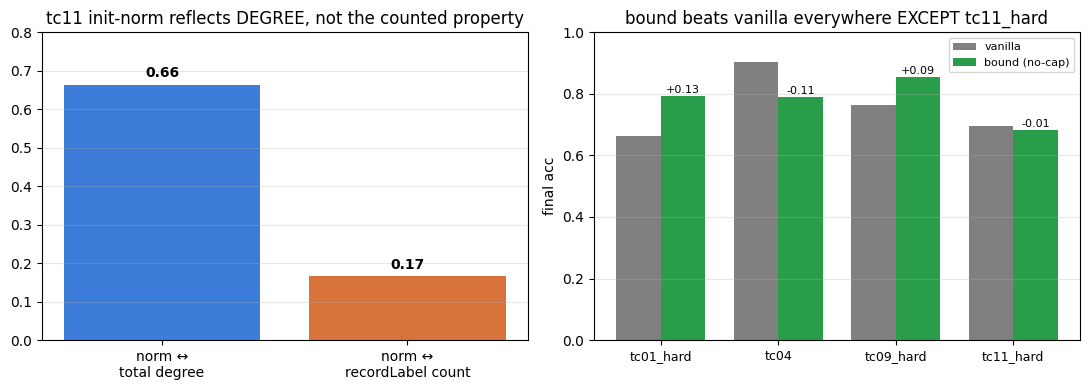

Where the bound has a real feature channel it wins; on tc11_hard (no recordLabel
code) it only ties vanilla, so the cap verdict sits inside the domain-noise band.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (left) norm tracks degree, not the counted property
d = R["degree_corr"]["tc11_hard"]
axes[0].bar(["norm ↔\ntotal degree", "norm ↔\nrecordLabel count"],
            [d["spearman_norm_degree"], d["spearman_norm_recordLabelcount"]],
            color=["#3b7dd8", "#d8743b"])
axes[0].set_ylim(0, 0.8); axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_title("tc11 init-norm reflects DEGREE, not the counted property")
for i, v in enumerate([d["spearman_norm_degree"], d["spearman_norm_recordLabelcount"]]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# (right) tc11_hard is the rare split where bound only ties vanilla
tcs = ["tc01_hard", "tc04", "tc09_hard", "tc11_hard"]
x = np.arange(len(tcs)); w = 0.38
van = [R["pipeline_accs"][t]["vanilla"] for t in tcs]
bnd = [R["pipeline_accs"][t]["nocap_final"] for t in tcs]
axes[1].bar(x - w/2, van, w, color="gray", label="vanilla")
axes[1].bar(x + w/2, bnd, w, color="#2a9d4a", label="bound (no-cap)")
axes[1].set_xticks(x); axes[1].set_xticklabels(tcs, fontsize=9)
axes[1].set_ylim(0, 1.0); axes[1].set_ylabel("final acc")
axes[1].set_title("bound beats vanilla everywhere EXCEPT tc11_hard")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.3)
for i, t in enumerate(tcs):
    axes[1].text(i + w/2, bnd[i] + 0.01, f"{bnd[i]-van[i]:+.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

print("Where the bound has a real feature channel it wins; on tc11_hard (no recordLabel")
print("code) it only ties vanilla, so the cap verdict sits inside the domain-noise band.")

## 5 · The rejected hypothesis: "capping unfreezes the positive hubs"

It is tempting to explain the drop mechanically: `tc11` positives are high-degree
hubs, so they fill the heavy-norm tail (16% of positives vs 6% of negatives have
norm > 16); un-capped, that tail is **frozen** (cos(init,final) ≈ 0.98), capped it
**drifts** (cos ≈ 0.90). The descriptive facts are true — but they do **not** explain
the drop, for three reasons an adversarial check surfaced:

1. **The control `tc09_hard` shows the *same* freeze→drift and the cap *helps* it.**
   tc09 tail cos goes 0.97 → 0.91 (essentially identical to tc11's 0.98 → 0.91), yet
   cap nets **+0.049** there. Same lever, opposite outcome ⇒ the lever isn't the cause.
2. **Capping does not change the norm's separating power** — `AUC(norm→label)` is
   0.637 before and 0.637 after the cap.
3. **At the entity level, capping *helps* the `tc11` tail too** (+0.02), and the body
   (+0.05). There is no entity-level harm anywhere to source the macro −0.034 from.

The two panels below show (left) the identical freeze→drift in both tasks, and
(right) that capping raises entity-level accuracy on every segment — body and tail,
tc11 and tc09. The −0.034 is therefore not in the entities; it is in the
equal-weighting of the two tiny domains (§3).

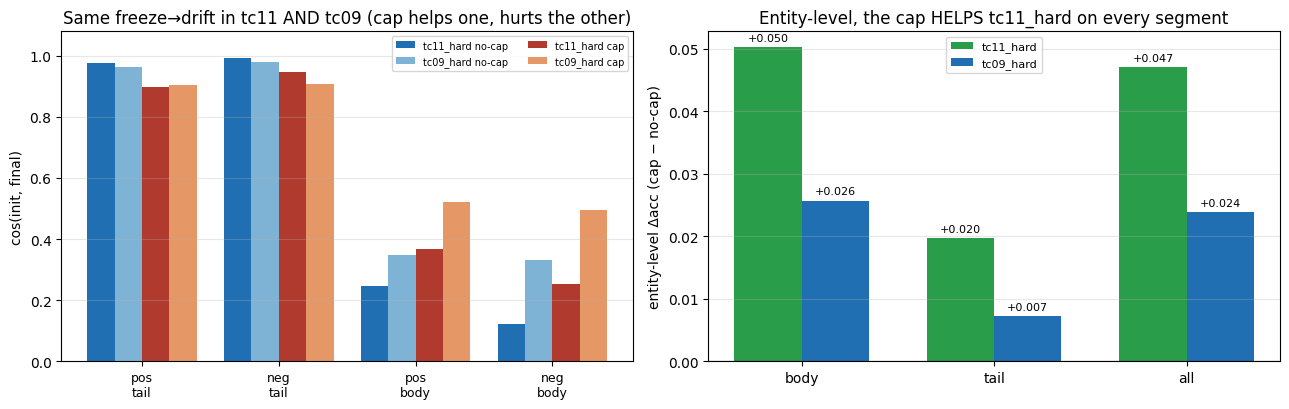

tc11_hard entity-level (micro): body Δ=+0.050  tail Δ=+0.020  all Δ=+0.047


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (left) freeze -> drift identical in tc11 and tc09
ax = axes[0]
groups = ["pos_tail", "neg_tail", "pos_body", "neg_body"]
xlab = ["pos\ntail", "neg\ntail", "pos\nbody", "neg\nbody"]
x = np.arange(len(groups)); w = 0.2
for off, tc, col in [(-1.5*w, "tc11_hard", "#1f6fb2"), (-0.5*w, "tc09_hard", "#7fb3d5")]:
    dd = R["drift"][tc]
    ax.bar(x + off, [dd[g]["cos_nocap"] for g in groups], w, color=col, label=f"{tc} no-cap")
for off, tc, col in [(0.5*w, "tc11_hard", "#b03a2e"), (1.5*w, "tc09_hard", "#e59866")]:
    dd = R["drift"][tc]
    ax.bar(x + off, [dd[g]["cos_cap"] for g in groups], w, color=col, label=f"{tc} cap")
ax.set_xticks(x); ax.set_xticklabels(xlab, fontsize=9)
ax.set_ylabel("cos(init, final)"); ax.set_ylim(0, 1.08)
ax.set_title("Same freeze→drift in tc11 AND tc09 (cap helps one, hurts the other)")
ax.legend(fontsize=7, ncol=2); ax.grid(axis="y", alpha=0.3)

# (right) entity-level cap effect is POSITIVE on every segment
ax = axes[1]
segs = ["body", "tail", "all"]
x = np.arange(len(segs)); w = 0.35
for off, tc, col in [(-w/2, "tc11_hard", "#2a9d4a"), (w/2, "tc09_hard", "#1f6fb2")]:
    tb = R["tail_body_final"][tc]
    deltas = [tb[s]["cap_acc"] - tb[s]["nocap_acc"] for s in segs]
    ax.bar(x + off, deltas, w, color=col, label=tc)
    for i, dv in enumerate(deltas):
        ax.text(i + off, dv + 0.001, f"{dv:+.3f}", ha="center", fontsize=8)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(segs)
ax.set_ylabel("entity-level Δacc (cap − no-cap)")
ax.set_title("Entity-level, the cap HELPS tc11_hard on every segment")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

tb = R["tail_body_final"]["tc11_hard"]
print(f"tc11_hard entity-level (micro): body Δ={tb['body']['cap_acc']-tb['body']['nocap_acc']:+.3f}  "
      f"tail Δ={tb['tail']['cap_acc']-tb['tail']['nocap_acc']:+.3f}  "
      f"all Δ={tb['all']['cap_acc']-tb['all']['nocap_acc']:+.3f}")

## 6 · Conclusion

**Direct answer to "why do the capped methods drop on `tc11_hard`?"** — They don't,
in any robust sense. The −0.034 is a fragile domain-averaging artifact:

- it **reverses** under the raw lens (+0.054), under the decay init (+0.011), and
  under entity-weighting (micro +0.047);
- it is produced **almost entirely by `movies_hard` (8 test entities, 3 flips)**;
  removing that one domain turns the domain-mean **positive (+0.034)**;
- on every large, reliable domain (`people` n=8000, `books` n=1028, `species`,
  `cities`) the cap **helps**, and so does the entity-level average.

**Why `tc11_hard` is uniquely noise-sensitive (the real finding).** Of all the
splits, it is the only one where the bound merely *ties* vanilla instead of beating
it, because the construction has **no `recordLabel` channel**: `recordLabel` is a
code-less relation, so every record-label edge is skipped and the init falls back on
an incidental degree proxy. When two methods are tied, the equal-weighted mean of six
domains — two of which have <15 test entities — can swing ±0.05 on noise, and on this
particular run it swung negative.

**Practical takeaways for the thesis.**

1. **Don't over-read the `tc11_hard` cap cell.** Report it with the per-domain sizes
   and/or the raw-lens number, or note that excluding the 8-entity `movies` domain
   reverses it. The defensible statement is "the cap is within noise on `tc11_hard`,"
   not "the cap hurts `tc11_hard`."
2. **The genuine `tc11` story is the missing channel.** The bound under-performs there
   — capped or not — because `recordLabel` has no protograph code. This is the same
   caution that applies to any qualified-cardinality task built on a relation that
   lacks clean domain/range axioms; the fix is to give such relations a code, not to
   touch the cap.
3. **Tiny DLCC domains need size-aware aggregation.** Several `_hard` splits
   (`tc11/movies` = 8, `tc11/albums` = 14, `tc11/cities` = 56) are too small for an
   equal-weighted domain-mean; a micro-average or a min-size filter would make the
   per-test-case table far less jumpy.

*(An earlier draft of this notebook proposed a "frozen positive-hub" mechanism for
the drop. §5 documents why that hypothesis was tested and rejected — the same
freeze→drift occurs in the `tc09_hard` control where the cap helps, capping leaves
`AUC(norm)` unchanged, and entity-level the cap helps the `tc11` tail. It is kept
here as a worked example of ruling a plausible story out with data.)*